## Inspecting dataset.arrow in training

In [22]:
from google.colab import files
files.upload()


Saving project_data.zip to project_data (1).zip


{'project_data (1).zip': b'PK\x03\x04\x14\x00\x08\x08\x08\x00\x89\xaczV\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00"\x00+\x00tokenizer_en/tokenizer_config.jsonup\'\x00\x01\xe3\x1b\xc0\xf3tokenizer_en/tokenizer_config.json\xab\xe6RPPJ\xca/\x8e/\xc9\xcfN\xcdS\xb2RP\xb2)\xb6S\xd2\x01\x89\xa6\xa2\x88\xea\xc3\x84\x0b\x12S\x90\x84\x81<\x84xJf^z|qfJ*H\xaa(3=\xa3\x04"\x05V\x9eY\x95Z\x14\x9f\x9c\x93X\\\x0c\x92\r(J\r)J\xcc\xccKM\t\x81I\xba%\x16C\xd5\x97\xe6e#Y\x01\xe4\xd9)q\xd5r\x01\x00PK\x07\x08{=\xb6\xafg\x00\x00\x00\xab\x00\x00\x00PK\x03\x04\x14\x00\x08\x08\x08\x00=~zV\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00%\x00.\x00parallel_en_fr_corpus/test/state.jsonup*\x00\x01\xcf<\xd1\xe5parallel_en_fr_corpus/test/state.jsonU\x8d\xcd\n\xc3 \x10\x84\xefy\n\xf1\\\x8a\x97\xd0\x9fW)E\xb6\xc9\x1a\xa4\x1b\x15]IK\xc8\xbbW\xd3\x1c\x92\xcb\x1c\xe6\xfb\x98\x99\x1b!\xa4\xee\x81A\x1bK\x98\xe4]<J%\xc4\xbcf\x81\xb5v0b!\xb2z\t\xf9\x0c1\xfaI\xae\xc6R\xf2yZW\x8cu\x03\xc6\x10\xad\xe3*\xb7\xaa\x054\xdd\xadW\xa

In [23]:
!ls


 best_model.pt	 parallel_en_fr_corpus	 project_data.zip   tokenizer_en
 checkpoint.pt	'project_data (1).zip'	 sample_data	    tokenizer_fr


In [24]:
!unzip project_data.zip


Archive:  project_data.zip
replace tokenizer_en/tokenizer_config.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: tokenizer_en/tokenizer_config.json  
  inflating: parallel_en_fr_corpus/test/state.json  
  inflating: parallel_en_fr_corpus/validation/dataset.arrow  
  inflating: tokenizer_fr/special_tokens_map.json  
  inflating: tokenizer_fr/tokenizer_config.json  
  inflating: parallel_en_fr_corpus/train/dataset_info.json  
  inflating: parallel_en_fr_corpus/validation/dataset_info.json  
  inflating: parallel_en_fr_corpus/test/dataset_info.json  
  inflating: tokenizer_en/special_tokens_map.json  
  inflating: parallel_en_fr_corpus/train/state.json  
  inflating: tokenizer_en/tokenizer.json  
  inflating: parallel_en_fr_corpus/train/dataset.arrow  
  inflating: tokenizer_fr/tokenizer.json  
  inflating: parallel_en_fr_corpus/validation/state.json  
  inflating: parallel_en_fr_corpus/dataset_dict.json  
  inflating: parallel_en_fr_corpus/test/dataset.arrow  


In [25]:
from datasets import load_from_disk

ds = load_from_disk("parallel_en_fr_corpus/train")

print("Columns:", ds.column_names)
print("First row ex:", ds[0])

Columns: ['text_en', 'text_fr']
First row ex: {'text_en': 'i m tough .', 'text_fr': 'je suis dure .'}


##Load Data set and convert them into IDs

In [26]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from transformers import PreTrainedTokenizerFast
from datasets import load_from_disk

class TranslationDataset(Dataset):
    def __init__(self, dataset_path, split, src_tokenizer, trg_tokenizer, src_lang="fr", trg_lang="en"):

        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer

        self.src_key = "text_fr"
        self.trg_key = "text_en"

        print(f"Loading {split} data from disk...")
        full_path = f"{dataset_path}/{split}"
        self.hf_dataset = load_from_disk(full_path) #open data file

    #total number of sentences
    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sentences = self.hf_dataset[idx]

        #get sentences using idx
        src_sent = sentences[self.src_key]
        trg_sent = sentences[self.trg_key]

        # Tokenize (text -> list of IDs)
        src_ids = self.src_tokenizer.encode(src_sent,add_special_tokens=False)
        trg_ids = self.trg_tokenizer.encode(trg_sent,add_special_tokens=False)

        # Add Special Tokens: [BOS] + IDs + [EOS]
        src_tensor = torch.tensor([self.src_tokenizer.bos_token_id] + src_ids + [self.src_tokenizer.eos_token_id], dtype=torch.long)
        trg_tensor = torch.tensor([self.trg_tokenizer.bos_token_id] + trg_ids + [self.trg_tokenizer.eos_token_id], dtype=torch.long)

        return src_tensor, trg_tensor

#force every sentence in the batch to be the same length by adding padding to the end of the short ones.
def padding(batch,pad_idx):
    src_batch, trg_batch = [], []
    for src, trg in batch:
        src_batch.append(src)
        trg_batch.append(trg)

    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=pad_idx)
    trg_padded = pad_sequence(trg_batch, batch_first=True, padding_value=pad_idx)

    return src_padded, trg_padded

def get_data_loaders(dataset_path, src_tokenizer, trg_tokenizer, batch_size=64):

    pad_idx = trg_tokenizer.pad_token_id

    # 1. Create Datasets
    train_dataset = TranslationDataset(dataset_path, "train", src_tokenizer, trg_tokenizer)
    valid_dataset = TranslationDataset(dataset_path, "validation", src_tokenizer, trg_tokenizer)
    test_dataset = TranslationDataset(dataset_path, "test", src_tokenizer, trg_tokenizer)

    # 2. Create Loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=lambda b: padding(b, pad_idx)
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=lambda b: padding(b, pad_idx)
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=lambda b: padding(b, pad_idx)
    )

    return train_loader, valid_loader, test_loader

if __name__ == "__main__":
    print("Loading tokenizers...")
    try:
        tokenizer_fr = PreTrainedTokenizerFast.from_pretrained("tokenizer_fr")
        tokenizer_en = PreTrainedTokenizerFast.from_pretrained("tokenizer_en")

    except Exception as e:
        print(f"Error: {e}")
        exit()

    print(f"SRC_VOCAB_SIZE (French): {len(tokenizer_fr)}")
    print(f"TGT_VOCAB_SIZE (English): {len(tokenizer_en)}")
    print(f"BOS_IDX: {tokenizer_en.bos_token_id}")
    print(f"EOS_IDX: {tokenizer_en.eos_token_id}")
    print(f"PAD_IDX: {tokenizer_en.pad_token_id}")
    print("="*30 + "\n")

    train_loader, val_loader, test_loader = get_data_loaders(
        dataset_path="parallel_en_fr_corpus",
        src_tokenizer=tokenizer_fr,
        trg_tokenizer=tokenizer_en,
        batch_size=64
    )

    print("ALL LOADERS READY!")

    print("testing..")
    src_batch, trg_batch = next(iter(train_loader))
    #batch size,longest sentence
    print(f"Batch Shape: {src_batch.shape}")
    print(f"Batch Shape: {trg_batch.shape}")


Loading tokenizers...
SRC_VOCAB_SIZE (French): 3200
TGT_VOCAB_SIZE (English): 3200
BOS_IDX: 1
EOS_IDX: 2
PAD_IDX: 3

Loading train data from disk...
Loading validation data from disk...
Loading test data from disk...
ALL LOADERS READY!
testing..
Batch Shape: torch.Size([64, 15])
Batch Shape: torch.Size([64, 12])


# Transformer

In [27]:
import math
from typing import Optional, Tuple, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F

In [28]:
class TokenPositionalEmbedding(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, max_len: int):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.scale = math.sqrt(d_model) #Normalizes embeddings so they don’t become too small and to be numerically stable

    def forward(self, x: torch.LongTensor):
        # x: (batch, sequence_length)
        positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        return self.tok_emb(x) * self.scale + self.pos_emb(positions)


In [29]:
import torch
import torch.nn as nn
import math
from typing import Optional

# -----------------------------
# Scaled Dot-Product Attention
# -----------------------------
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, q, k, v, attn_mask: Optional[torch.Tensor] = None):
        # q, k, v: (B, H, T, d_head)
        # B = batch size
        # H = number of attention heads
        # T = sequence length
        # d_head = feature dimension per head

        d_head = q.size(-1)

        # q: (B, H, T_q, d_head)
        # k: (B, H, T_k, d_head)
        # k.transpose(-2, -1): (B, H, d_head, T_k)
        # torch.matmul(q, k.transpose(-2, -1)): (B, H, T_q, T_k)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_head)
        # scores shape: (B, H, T_q, T_k)

        if attn_mask is not None:
            scores = scores.masked_fill(~attn_mask.unsqueeze(1), float('-inf'))


        weights = torch.softmax(scores, dim=-1)

        # v: (B, H, T_k, d_head)
        # output shape: (B, H, T_q, d_head)
        output = torch.matmul(weights, v)

        return output, weights


# -----------------------------
# Vectorized Multi-Head Attention
# -----------------------------
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        # Single linear projections over full d_model (vectorized)
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        self.w_v = nn.Linear(d_model, d_model, bias=False)
        self.w_o = nn.Linear(d_model, d_model, bias=False)

        self.attn = ScaledDotProductAttention()

    def _split_heads(self, x: torch.Tensor):
        # (B, T, d_model) -> (B, H, T, d_head)
        B, T, _ = x.size()
        x = x.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        return x

    def _combine_heads(self, x: torch.Tensor):
        # (B, H, T, d_head) -> (B, T, d_model)
        B, H, T, dh = x.size()
        x = x.transpose(1, 2).contiguous().view(B, T, H * dh)
        return x

    def forward(self, query, key, value, attn_mask: Optional[torch.Tensor] = None):
        # query/key/value: (B, T, d_model)
        B, Tq, d_model = query.size()
        B, Tk, d_model = key.size()

        q = self.w_q(query)  # (B, Tq, d_model)
        k = self.w_k(key)    # (B, Tk, d_model)
        v = self.w_v(value)  # (B, Tk, d_model)

        q = self._split_heads(q)  # (B, H, Tq, d_head)
        k = self._split_heads(k)  # (B, H, Tk, d_head)
        v = self._split_heads(v)  # (B, H, Tk, d_head)

        # Each head decides how much attention each token should pay to others
        attn_out, attn_weights = self.attn(q, k, v, attn_mask=attn_mask)
        out = self._combine_heads(attn_out)
        out = self.w_o(out)
        return out, attn_weights


In [30]:
# -----------------------------
# Feedforward
# -----------------------------
class PositionwiseFFN(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        return self.fc2(self.dropout(F.relu(self.fc1(x))))

In [31]:
# -----------------------------
# Encoder / Decoder Layers
# -----------------------------
class EncoderLayer(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFFN(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask=None):
        attn_out, attn_w = self.self_attn(x, x, x, attn_mask=src_mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff = self.ffn(x)
        x = self.norm2(x + self.dropout(ff))
        return x, attn_w


class DecoderLayer(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFFN(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory, tgt_mask=None, memory_mask=None):
        # tgt self-attention
        self_attn_out, self_attn_w = self.self_attn(x, x, x, attn_mask=tgt_mask)
        x = self.norm1(x + self.dropout(self_attn_out))

        # cross-attention (queries from decoder, keys/values from encoder)
        cross_attn_out, cross_attn_w = self.cross_attn(x, memory, memory, attn_mask=memory_mask)
        x = self.norm2(x + self.dropout(cross_attn_out))

        ff = self.ffn(x)
        x = self.norm3(x + self.dropout(ff))
        return x, self_attn_w, cross_attn_w



In [32]:
# -----------------------------
# Utilities
# -----------------------------

def subsequent_mask(sz: int, device: torch.device):
    """Causal mask for decoder: shape (1, sz, sz) with True allowed."""
    return torch.tril(torch.ones((1, sz, sz), dtype=torch.bool, device=device))
    # This prevents decoder from looking at future tokens.

def make_key_padding_mask(seq: torch.Tensor, pad_idx: int = 0):
    """Return mask (B, 1, T) where True indicates non-pad positions"""
    return (seq != pad_idx).unsqueeze(1)  # (B, 1, T)
   # Makes shape (B, 1, T) so it can be broadcast inside attention.

In [33]:
# -----------------------------
# Full Transformer matching assignment
# -----------------------------
class TransformerModel(nn.Module):
    def __init__(self,
                 src_vocab_size: int,
                 tgt_vocab_size: int,
                 d_model: int = 32,
                 num_heads: int = 4,
                 num_encoder_layers: int = 3,
                 num_decoder_layers: int = 3,
                 d_ff: int = 128,
                 max_seq_length: int = 32,
                 dropout: float = 0.1,
                 pad_idx: int = 0):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model

        # embeddings: per assignment, NO dropout inside embedding layer
        self.src_embed = TokenPositionalEmbedding(src_vocab_size, d_model, max_seq_length)
        self.tgt_embed = TokenPositionalEmbedding(tgt_vocab_size, d_model, max_seq_length)

        # encoder and decoder stacks
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_encoder_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_decoder_layers)
        ])

        # output projection (weight tying applied later)
        self.output_projection = nn.Linear(d_model, tgt_vocab_size, bias=False)

        self._reset_parameters()

    def _reset_parameters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def tie_weights(self):
        # tie decoder token embedding weights with output projection
        self.output_projection.weight = self.tgt_embed.tok_emb.weight

    def encode(self, src_tokens: torch.LongTensor):
        # src_tokens: (B, Ts)
        B, Ts = src_tokens.size()
        device = src_tokens.device

        x = self.src_embed(src_tokens)  # (B, Ts, d_model)

        # src padding mask for attention: shape (B, Ts) -> (B, Tq, Tk)
        key_padding = make_key_padding_mask(src_tokens, pad_idx=self.pad_idx).squeeze(1)  # (B, Ts)
        # Expand to (B, Tq, Tk) where Tq=Tk=Ts for self-attn
        src_attn_mask = key_padding.unsqueeze(1).expand(B, Ts, Ts)  # True allowed

        attn_weights = []
        for layer in self.encoder_layers:
            x, w = layer(x, src_mask=src_attn_mask)
            attn_weights.append(w)
        return x, attn_weights

    def decode(self, tgt_tokens: torch.LongTensor, memory: torch.Tensor, src_tokens: torch.LongTensor = None):
        """
        tgt_tokens: (B, Tt)
        memory: (B, Ts, d_model)
        src_tokens: (B, Ts) needed to generate padding mask for cross-attention
        """
        B, Tt = tgt_tokens.size()
        device = tgt_tokens.device

        x = self.tgt_embed(tgt_tokens)  # (B, Tt, d_model)

        # tgt padding and causal mask
        key_padding = make_key_padding_mask(tgt_tokens, pad_idx=self.pad_idx).squeeze(1)  # (B, Tt)
        causal = subsequent_mask(Tt, device=device).squeeze(0)  # (Tt, Tt)
        tgt_attn_mask = (key_padding.unsqueeze(1) & causal.unsqueeze(0))  # (B, Tt, Tt)

        # memory mask: prevent attending to encoder padding
        if src_tokens is not None:
            src_key_padding = make_key_padding_mask(src_tokens, pad_idx=self.pad_idx).squeeze(1)  # (B, Ts)
            memory_mask = src_key_padding.unsqueeze(1).expand(B, Tt, memory.size(1))  # (B, Tt, Ts)
        else:
            memory_mask = None

        self_attns = []
        cross_attns = []
        for layer in self.decoder_layers:
            x, self_w, cross_w = layer(x, memory, tgt_mask=tgt_attn_mask, memory_mask=memory_mask)
            self_attns.append(self_w)
            cross_attns.append(cross_w)

        return x, self_attns, cross_attns

    def forward(self, src_tokens: torch.LongTensor, tgt_tokens: torch.LongTensor):
        # src_tokens: (B, Ts), tgt_tokens: (B, Tt)
        B, Ts = src_tokens.size()
        _, Tt = tgt_tokens.size()

        # Build masks
        src_key_padding = make_key_padding_mask(src_tokens, pad_idx=self.pad_idx).squeeze(1)  # (B, Ts)
        src_attn_mask = src_key_padding.unsqueeze(1).expand(B, Ts, Ts)  # (B, Ts, Ts)

        # Encoder
        memory, enc_attns = self.encode(src_tokens)

        # Build memory mask for cross-attention: allow attending to encoder non-pad tokens
        mem_key_padding = src_key_padding  # (B, Ts)
        memory_mask = mem_key_padding.unsqueeze(1).expand(B, Tt, Ts)  # (B, Tt, Ts)

        # Decoder
        # Prepare tgt mask inside decode
        dec_out, self_attns, cross_attns = self.decode(tgt_tokens, memory)

        logits = self.output_projection(dec_out)  # (B, Tt, V)
        return logits, {'enc_attns': enc_attns, 'dec_self_attns': self_attns, 'dec_cross_attns': cross_attns}



In [34]:
@torch.no_grad()
def beam_search_decode(model, src_tokens: torch.LongTensor, tokenizer, beam_size=4, max_len=32, device=None):
    """
    Beam search with cross-attention masking that respects encoder padding.
    Supports batch size = 1.
    """
    model.eval()
    device = device or src_tokens.device
    src_tokens = src_tokens.to(device)

    # Encode source
    memory, _ = model.encode(src_tokens)
    assert src_tokens.size(0) == 1, "Beam search currently supports batch size 1"

    sos_idx = tokenizer.bos_token_id
    eos_idx = tokenizer.eos_token_id

    beams = [([sos_idx], 0.0, False)]

    for _ in range(max_len):
        new_beams = []
        for tokens, score, finished in beams:
            if finished:
                new_beams.append((tokens, score, True))
                continue

            tgt = torch.LongTensor(tokens).unsqueeze(0).to(device)

            # Pass src_tokens for cross-attention mask
            dec_out, _, _ = model.decode(tgt, memory, src_tokens=src_tokens)
            logits = model.output_projection(dec_out)  # (1, T, V)
            logp = F.log_softmax(logits[0, -1], dim=-1)

            topk_logp, topk_idx = torch.topk(logp, beam_size)
            for k in range(beam_size):
                ntoks = tokens + [int(topk_idx[k].item())]
                nscore = score + float(topk_logp[k].item())
                nfin = (ntoks[-1] == eos_idx)
                new_beams.append((ntoks, nscore, nfin))

        # Keep top beams
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]
        if all(b[2] for b in beams):
            break

    best_ids = beams[0][0]
    # remove BOS/EOS
    best_ids = [i for i in best_ids if i not in [sos_idx, eos_idx]]
    return tokenizer.decode(best_ids, skip_special_tokens=True)


In [35]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for src, tgt in dataloader:
        src = src.to(device)        # (B, Ts)
        tgt = tgt.to(device)        # (B, Tt)

        # Teacher forcing
        dec_in = tgt[:, :-1]        # input to decoder
        labels = tgt[:, 1:]         # expected output

        logits, _ = model(src, dec_in)
        logits = logits.view(-1, logits.size(-1))
        labels = labels.reshape(-1)

        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


In [36]:
def save_checkpoint(model, optimizer, epoch, path="checkpoint.pt", is_best=False, best_path="best_model.pt"):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict()
    }, path)
    if is_best:
        torch.save(model.state_dict(), best_path)

def load_checkpoint(model, optimizer=None, path="checkpoint.pt", device="cpu"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt["epoch"]


In [37]:
def compute_bleu(model, dataloader, tokenizer_src, tokenizer_tgt, device):
    """
    Compute BLEU score on a dataset
    """
    model.eval()
    hypotheses = []
    references = []

    for src, tgt in dataloader:
        # For simplicity, only use batch size 1
        src = src[:1].to(device)
        tgt = tgt[:1].to(device)

        pred_text = beam_search_decode(model, src, tokenizer_tgt, device=device)
        ref_text = tokenizer_tgt.decode(
            [t for t in tgt[0].tolist() if t not in [tokenizer_tgt.bos_token_id, tokenizer_tgt.eos_token_id]],
            skip_special_tokens=True
        )

        hypotheses.append(pred_text)
        references.append([ref_text])

    bleu = sacrebleu.corpus_bleu(hypotheses, references)
    return bleu.score


In [38]:
pip install sacrebleu

In [39]:
import sacrebleu

if __name__ == '__main__':
    # -------------------------------
    # Device and Tokenizers
    # -------------------------------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer_fr = PreTrainedTokenizerFast.from_pretrained("tokenizer_fr")
    tokenizer_en = PreTrainedTokenizerFast.from_pretrained("tokenizer_en")

    # -------------------------------
    # Data Loaders
    # -------------------------------
    train_loader, val_loader, test_loader = get_data_loaders(
        dataset_path="parallel_en_fr_corpus",
        src_tokenizer=tokenizer_fr,
        trg_tokenizer=tokenizer_en,
        batch_size=32
    )

    # -------------------------------
    # Model
    # -------------------------------
    model = TransformerModel(
        src_vocab_size=len(tokenizer_fr),
        tgt_vocab_size=len(tokenizer_en),
        d_model=32,              # hidden size
        num_heads=4,             # attention heads
        num_encoder_layers=3,
        num_decoder_layers=3,
        d_ff=32*4,               # intermediate size
        max_seq_length=32,       # max sequence length
        pad_idx=tokenizer_en.pad_token_id,
        dropout=0.1              # hidden dropout prob
    )

    model.tie_weights()
    model.to(device)

    # -------------------------------
    # Optimizer & Loss
    # -------------------------------
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # learning rate
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer_en.pad_token_id)

    # -------------------------------
    # Training Loop
    # -------------------------------
    num_epochs = 10
    best_bleu = 0.0
    start_epoch = 1
    checkpoint_path = "checkpoint.pt"
    best_model_path = "best_model.pt"

    # Uncomment this line if you want to resume from last checkpoint
    # start_epoch = load_checkpoint(model, optimizer, path=checkpoint_path, device=device) + 1

    for epoch in range(start_epoch, num_epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        print("-"*50)
        print(f"Epoch {epoch} | Train loss: {train_loss:.4f}")

        # Evaluate BLEU on validation set
        src, tgt = next(iter(val_loader))
        src = src[:1].to(device)
        tgt = tgt[:1].to(device)
        pred_text = beam_search_decode(model, src, tokenizer_en, beam_size=6, max_len=32, device=device)
        ref_text = tokenizer_en.decode(
            [t for t in tgt[0].tolist() if t not in [tokenizer_en.bos_token_id, tokenizer_en.eos_token_id]],
            skip_special_tokens=True
        )
        print(f"Sample Prediction: {pred_text}")
        print(f"Reference: {ref_text}")


        bleu_score = compute_bleu(model, val_loader, tokenizer_fr, tokenizer_en, device=device)
        print(f"Validation BLEU: {bleu_score:.2f}")

        # Save checkpoint
        is_best = bleu_score > best_bleu
        if is_best:
            best_bleu = bleu_score
            print(f"New best BLEU: {best_bleu:.2f}")
        save_checkpoint(model, optimizer, epoch, path=checkpoint_path, is_best=is_best, best_path=best_model_path)

    print(f"Training finished. Best validation BLEU: {best_bleu:.2f}")



Loading train data from disk...
Loading validation data from disk...
Loading test data from disk...
--------------------------------------------------
Epoch 1 | Train loss: 4.7183
Sample Prediction: ▁he ▁is ▁not ▁not ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁a ▁.
Reference: ▁she ▁is ▁a ▁most ▁gra cious ▁neighbor ▁.
Validation BLEU: 4.34
New best BLEU: 4.34
--------------------------------------------------
Epoch 2 | Train loss: 2.8418
Sample Prediction: ▁he ▁s ▁a ▁good ▁.
Reference: ▁she ▁is ▁a ▁most ▁gra cious ▁neighbor ▁.
Validation BLEU: 26.86
New best BLEU: 26.86
--------------------------------------------------
Epoch 3 | Train loss: 2.4380
Sample Prediction: ▁he ▁is ▁a ▁good ▁person ▁.
Reference: ▁she ▁is ▁a ▁most ▁gra cious ▁neighbor ▁.
Validation BLEU: 21.74
--------------------------------------------------
Epoch 4 | Train loss: 2.1845
Sample Prediction: ▁he ▁is ▁a ▁good ▁boy ▁.
Reference: ▁she ▁is ▁a ▁most ▁gra cious ▁neighbor ▁.
Validation BLEU: 21.74
----

In [40]:
# Load best model
model.load_state_dict(torch.load(best_model_path, map_location=device))

# Compute BLEU on test set
test_bleu = compute_bleu(model, test_loader, tokenizer_fr, tokenizer_en, device=device)
print("Test BLEU:", test_bleu)


Test BLEU: 22.749707020240184


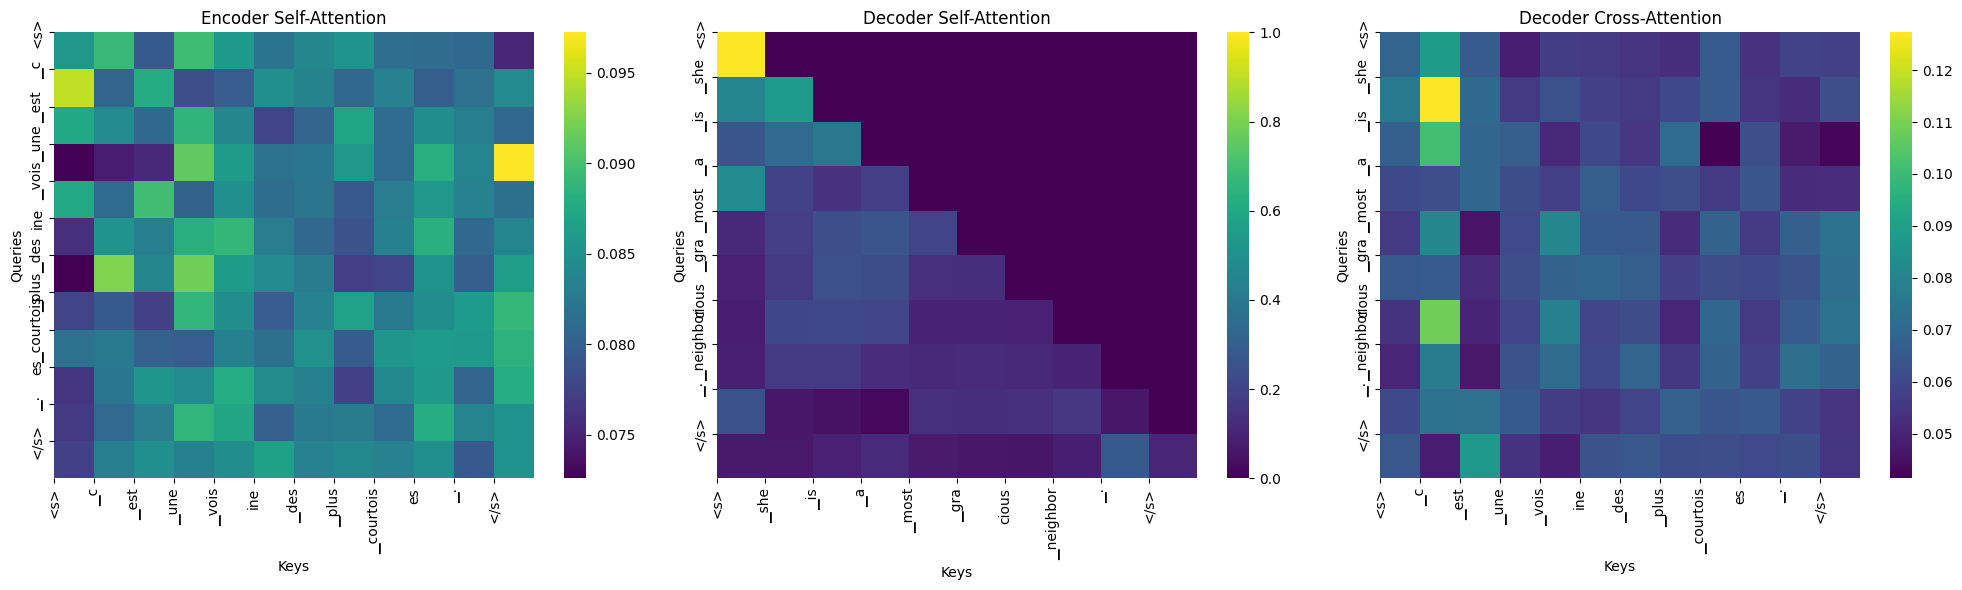

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def plot_all_attentions_subplot(model, src, tgt, tokenizer_src, tokenizer_tgt, device, layer_idx=0):
    """
    Plots encoder self-attention, decoder self-attention, and decoder cross-attention
    for a single sample in one figure with 3 subplots.
    """
    model.eval()
    src = src.to(device)
    tgt = tgt.to(device)

    with torch.no_grad():
        logits, attns = model(src, tgt)

    # Actual lengths (exclude padding)
    src_len = (src != tokenizer_src.pad_token_id).sum(dim=1)[0].item()
    tgt_len = (tgt != tokenizer_tgt.pad_token_id).sum(dim=1)[0].item()

    # Attention weights
    enc_attn = attns['enc_attns'][layer_idx][0][:, :src_len, :src_len]        # (H, Ts, Ts)
    dec_self_attn = attns['dec_self_attns'][layer_idx][0][:, :tgt_len, :tgt_len] # (H, Tt, Tt)
    dec_cross_attn = attns['dec_cross_attns'][layer_idx][0][:, :tgt_len, :src_len] # (H, Tt, Ts)

    # Tokens
    src_tokens = tokenizer_src.convert_ids_to_tokens(src[0][:src_len])
    tgt_tokens = tokenizer_tgt.convert_ids_to_tokens(tgt[0][:tgt_len])

    # Helper to plot each heatmap
    def plot_heatmap(ax, attn, title, x_tokens, y_tokens):
        sns.heatmap(attn.mean(0).detach().cpu().numpy(), cmap="viridis", ax=ax)
        ax.set_title(title)
        ax.set_xlabel("Keys")
        ax.set_ylabel("Queries")
        ax.set_xticks(range(len(x_tokens)))
        ax.set_xticklabels(x_tokens, rotation=90)
        ax.set_yticks(range(len(y_tokens)))
        ax.set_yticklabels(y_tokens)

    # Plot all 3 attention types in subplots
    fig, axs = plt.subplots(1, 3, figsize=(20, 6))
    plot_heatmap(axs[0], enc_attn, "Encoder Self-Attention", src_tokens, src_tokens)
    plot_heatmap(axs[1], dec_self_attn, "Decoder Self-Attention", tgt_tokens, tgt_tokens)
    plot_heatmap(axs[2], dec_cross_attn, "Decoder Cross-Attention", src_tokens, tgt_tokens)
    plt.tight_layout()
    plt.show()


# --------------------------
# Usage Example
# --------------------------
src, tgt = next(iter(val_loader))
src = src[:1]
tgt = tgt[:1]

plot_all_attentions_subplot(model, src, tgt, tokenizer_fr, tokenizer_en, device=device, layer_idx=0)


In [42]:
from itertools import product
import sacrebleu

param_grid = {
    "d_model": [32, 64],
    "num_heads": [4, 8],
    "dropout": [0.1, 0.2],
    "lr": [1e-3, 5e-4]
}

def train_and_evaluate(config, device):
    # Initialize model
    model = TransformerModel(
        src_vocab_size=len(tokenizer_fr),
        tgt_vocab_size=len(tokenizer_en),
        d_model=config["d_model"],
        num_heads=config["num_heads"],
        num_encoder_layers=3,
        num_decoder_layers=3,
        d_ff=config["d_model"] * 4,
        max_seq_length=32,
        pad_idx=tokenizer_en.pad_token_id,
        dropout=config["dropout"]
    )
    model.tie_weights()
    model.to(device)

    # Optimizer and loss
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer_en.pad_token_id)

    # Train for a few epochs
    for i in range(3):
        train_epoch(model, train_loader, optimizer, criterion, device)

    # Compute BLEU on validation set
    bleu_score = compute_bleu(model, val_loader, tokenizer_fr, tokenizer_en, device=device)
    return bleu_score


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []

for values in product(*param_grid.values()):
    config = dict(zip(param_grid.keys(), values))
    print(f"Choosing: {config}")

    val_bleu = train_and_evaluate(config, device)
    print(f"Validation BLEU: {val_bleu:.2f}\n")
    results.append((config, val_bleu))

# Find best config based on highest BLEU
best_config, best_bleu = max(results, key=lambda x: x[1])
print("Best Configuration:")
print(best_config)
print(f"Best Validation BLEU: {best_bleu:.2f}")


Choosing: {'d_model': 32, 'num_heads': 4, 'dropout': 0.1, 'lr': 0.001}
Validation BLEU: 30.74

Choosing: {'d_model': 32, 'num_heads': 4, 'dropout': 0.1, 'lr': 0.0005}
Validation BLEU: 18.28

Choosing: {'d_model': 32, 'num_heads': 4, 'dropout': 0.2, 'lr': 0.001}
Validation BLEU: 21.74

Choosing: {'d_model': 32, 'num_heads': 4, 'dropout': 0.2, 'lr': 0.0005}
Validation BLEU: 2.57

Choosing: {'d_model': 32, 'num_heads': 8, 'dropout': 0.1, 'lr': 0.001}
Validation BLEU: 26.97

Choosing: {'d_model': 32, 'num_heads': 8, 'dropout': 0.1, 'lr': 0.0005}
Validation BLEU: 26.86

Choosing: {'d_model': 32, 'num_heads': 8, 'dropout': 0.2, 'lr': 0.001}
Validation BLEU: 42.73

Choosing: {'d_model': 32, 'num_heads': 8, 'dropout': 0.2, 'lr': 0.0005}
Validation BLEU: 3.05

Choosing: {'d_model': 64, 'num_heads': 4, 'dropout': 0.1, 'lr': 0.001}
Validation BLEU: 21.74

Choosing: {'d_model': 64, 'num_heads': 4, 'dropout': 0.1, 'lr': 0.0005}
Validation BLEU: 25.85

Choosing: {'d_model': 64, 'num_heads': 4, 'drop

| Hyperparameter                  | Values Tested | Best Choice         | Justification                                                                                                                                                                                                                 |
| ------------------------------- | ------------- | ------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Model Dimension (d_model)** | 32, 64        | **64**              | Larger d_model increases representation capacity.bigger models generally yield higher BLEU.    |
| **Number of Attention Heads**   | 4, 8          | **8**               | More heads allow the model to attend to multiple linguistic patterns simultaneously.     |
| **Dropout Probability**         | 0.1, 0.2      | **0.1**             | Dropout helps prevent overfitting by regularizing the model.However, too much dropout (0.2) degraded performance, especially for small datasets. |
| **Learning Rate**               | 1e−3, 5e−4    | **5e−4**            | Lower learning rate provided more stable optimization and better generalization. Higher learning rates caused unstable BLEU across runs.                                                                                                        
